# Imports and data loading

In [27]:
# import kagglehub
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [69]:
# path = "../" + kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# print("Path to dataset files:", path)

# Dataset Exploration

In [28]:
DATA_PATH = "../data/raw/"
os.listdir(DATA_PATH)

['COVID',
 'COVID.metadata.xlsx',
 'Lung_Opacity',
 'Lung_Opacity.metadata.xlsx',
 'Normal',
 'Normal.metadata.xlsx',
 'README.md.txt',
 'Viral Pneumonia',
 'Viral Pneumonia.metadata.xlsx']

In [29]:
normal_metadata = pd.read_excel(os.path.join(DATA_PATH, "Normal.metadata.xlsx"))
covid_metadata = pd.read_excel(os.path.join(DATA_PATH, "COVID.metadata.xlsx"))
lung_opacity_metadata = pd.read_excel(os.path.join(DATA_PATH, "Lung_Opacity.metadata.xlsx"))
viral_pneumonia_metadata = pd.read_excel(os.path.join(DATA_PATH, "Viral Pneumonia.metadata.xlsx"))

In [30]:
df = (normal_metadata, "normal")
df = (covid_metadata, "covid")
# df = (lung_opacity_metadata, "lung_opacity")
# df = (viral_pneumonia_metadata, "viral_pneumonia")
print(df[1])
print(df[0].shape)
df[0].head(10)

covid
(3616, 4)


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
5,COVID-6,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
6,COVID-7,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
7,COVID-8,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
8,COVID-9,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
9,COVID-10,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


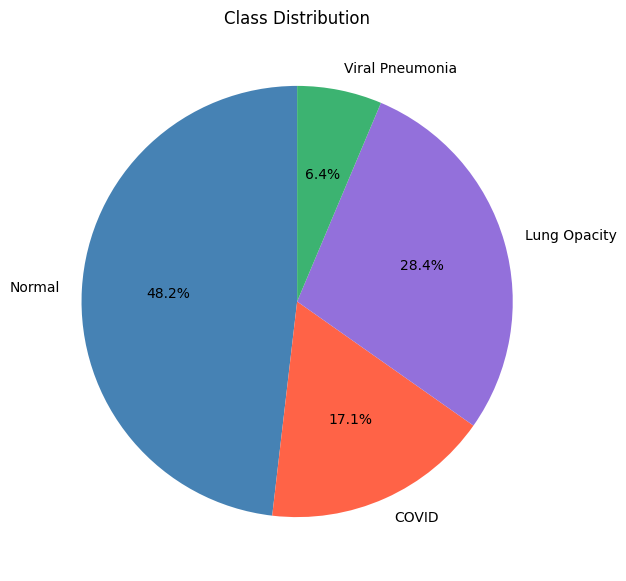

In [31]:
normal_count = normal_metadata.shape[0]
covid_count = covid_metadata.shape[0]
lung_opacity_count = lung_opacity_metadata.shape[0]
viral_pneumonia_count = viral_pneumonia_metadata.shape[0]

labels = ['Normal', 'COVID', 'Lung Opacity', 'Viral Pneumonia', 'Total Affected']
counts = [normal_count, covid_count, lung_opacity_count, viral_pneumonia_count, covid_count + lung_opacity_count + viral_pneumonia_count]

plt.figure(figsize=(7, 7))
plt.pie(counts[:-1], labels=labels[:-1], colors=['steelblue', 'tomato', 'mediumpurple', 'mediumseagreen', 'salmon'],
        autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.show()

We have imbalanced classes.

# Utility functions

In [8]:
!ls "..//kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images"

'Viral Pneumonia-1000.png'  'Viral Pneumonia-396.png'
'Viral Pneumonia-1001.png'  'Viral Pneumonia-397.png'
'Viral Pneumonia-1002.png'  'Viral Pneumonia-398.png'
'Viral Pneumonia-1003.png'  'Viral Pneumonia-399.png'
'Viral Pneumonia-1004.png'  'Viral Pneumonia-39.png'
'Viral Pneumonia-1005.png'  'Viral Pneumonia-3.png'
'Viral Pneumonia-1006.png'  'Viral Pneumonia-400.png'
'Viral Pneumonia-1007.png'  'Viral Pneumonia-401.png'
'Viral Pneumonia-1008.png'  'Viral Pneumonia-402.png'
'Viral Pneumonia-1009.png'  'Viral Pneumonia-403.png'
'Viral Pneumonia-100.png'   'Viral Pneumonia-404.png'
'Viral Pneumonia-1010.png'  'Viral Pneumonia-405.png'
'Viral Pneumonia-1011.png'  'Viral Pneumonia-406.png'
'Viral Pneumonia-1012.png'  'Viral Pneumonia-407.png'
'Viral Pneumonia-1013.png'  'Viral Pneumonia-408.png'
'Viral Pneumonia-1014.png'  'Viral Pneumonia-409.png'
'Viral Pneumonia-1015.png'  'Viral Pneumonia-40.png'
'Viral Pneumonia-1016.png'  'Viral Pneumonia-410.png'
'Viral Pneumonia-1017.png'  'Vir

In [32]:
normal_path = os.path.join(DATA_PATH, "Normal", "images")
covid_path = os.path.join(DATA_PATH, "COVID", "images")
lung_opacity_path = os.path.join(DATA_PATH, "Lung_Opacity", "images")
viral_pneumonia_path = os.path.join(DATA_PATH, "Viral Pneumonia", "images")

paths = {
    'Normal': normal_path,
    'COVID': covid_path,
    'Lung Opacity': lung_opacity_path,
    'Viral Pneumonia': viral_pneumonia_path
}

# Some examples

In [33]:
def show_examples(class_name, masked=False):
  path = paths[class_name]
  images = os.listdir(path)
  np.random.seed(42)
  
  if not masked:
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))

    for i in range(5):
      selected = images[np.random.randint(0, len(images))]
      selected_path = os.path.join(path, selected)
      image = plt.imread(selected_path)
      axs[0, 0].set_ylabel("IMAGES", fontsize=12)
      axs[i].imshow(image, cmap="gray")
      axs[i].set_title(selected)
      
  else:
    fig, axs = plt.subplots(3, 5, figsize=(15, 9))

    for i in range(5):
      selected = images[np.random.randint(0, len(images), )]
      selected_path = os.path.join(path, selected)
      image = plt.imread(selected_path)
      image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if len(image.shape) == 3 else image
      mask = plt.imread(selected_path.replace("images", "masks"))
      mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
      mask_resized = cv2.resize(mask_gray, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
      mask_bin = (mask_resized > 0).astype(image.dtype)
      image_masked = image * mask_bin
      axs[0, 0].set_ylabel("IMAGES", fontsize=12)
      axs[0, i].imshow(image, cmap="gray")
      axs[0, i].set_title(selected)
      axs[1, 0].set_ylabel("MASKS", fontsize=12)
      axs[1, i].imshow(mask_gray, cmap="gray")
      axs[2, 0].set_ylabel("MASKED IMAGES", fontsize=12)
      axs[2, i].imshow(image_masked, cmap="gray")

## Healthy Lungs

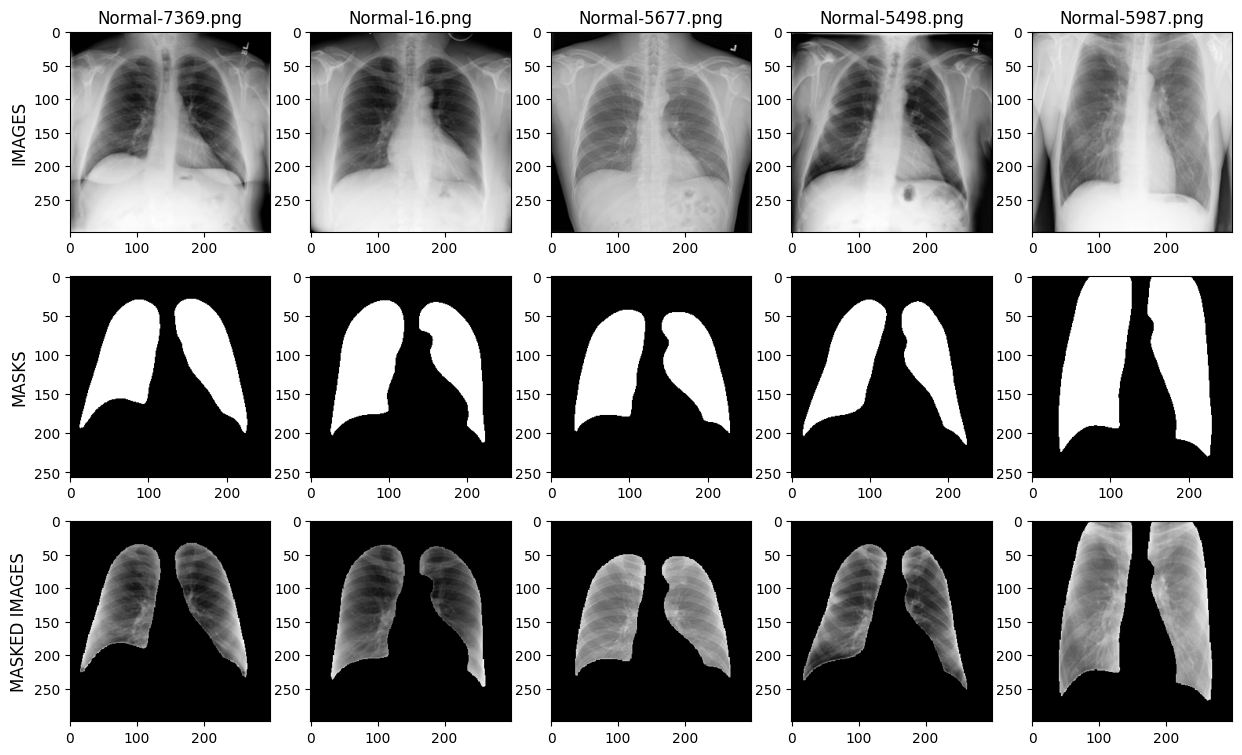

In [34]:
show_examples("Normal", masked=True)

## Affected lungs (COVID 19)

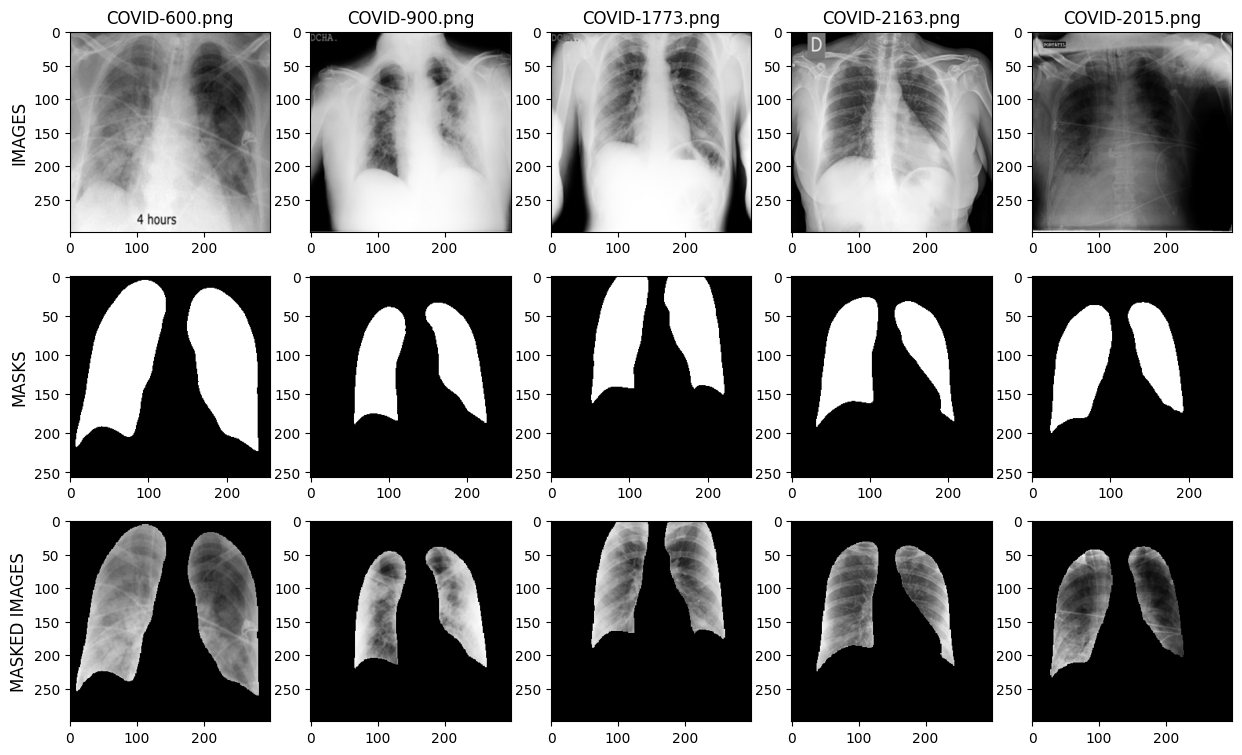

In [35]:
show_examples("COVID", masked=True)

## Affected lungs (Lung Opacity)

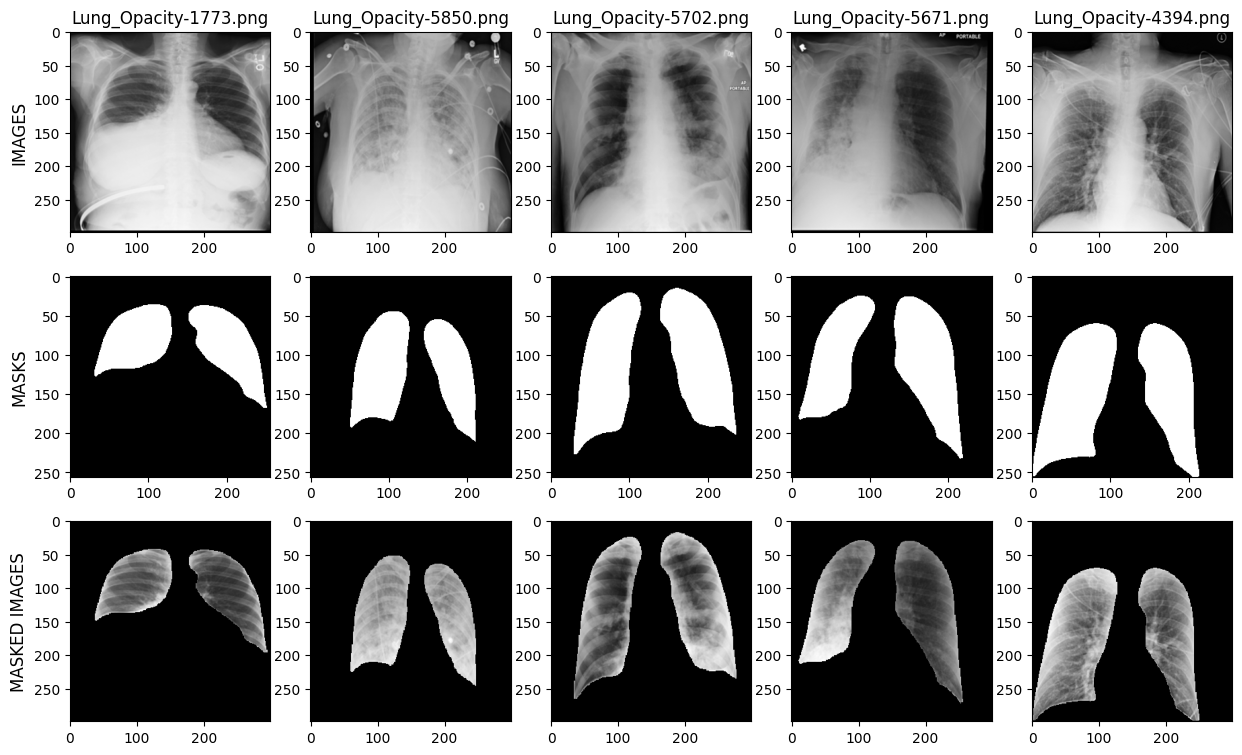

In [36]:
show_examples("Lung Opacity", masked=True)

## Affected Lungs (Viral Pneumonia)

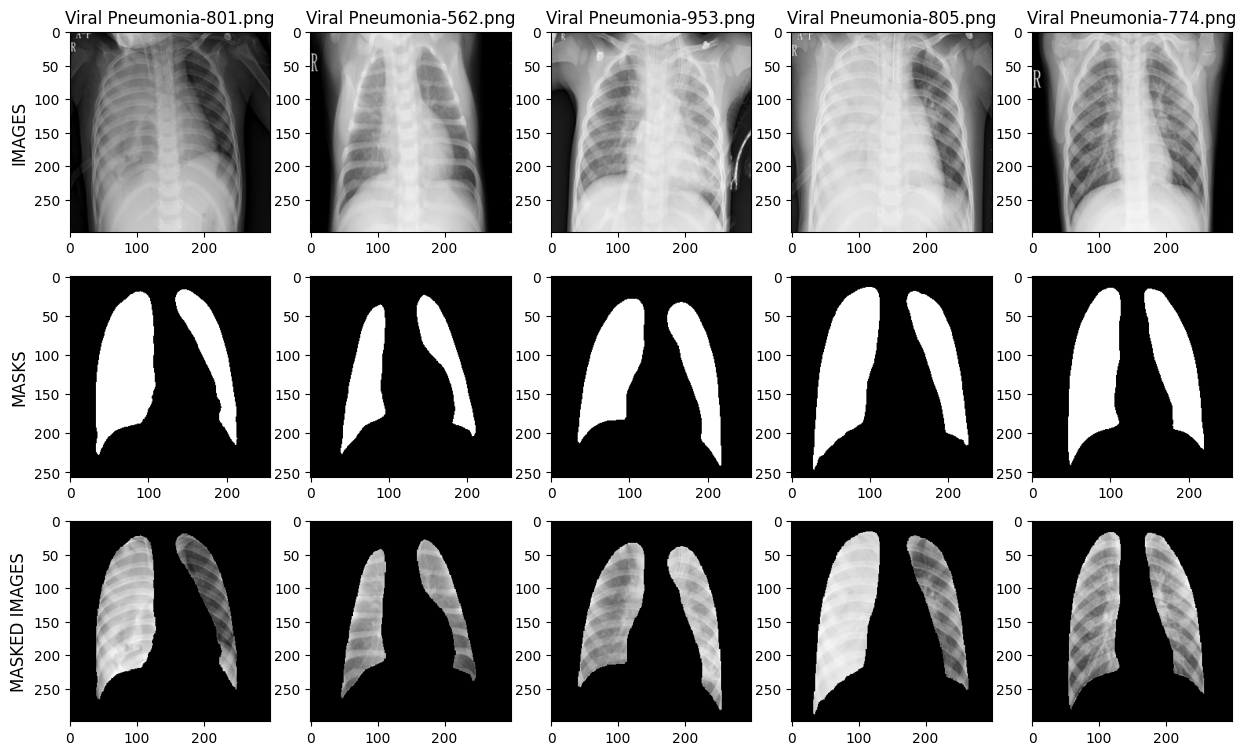

In [37]:
show_examples("Viral Pneumonia", masked=True)

# Shapes

In [38]:
def check_shapes(class_name, data="images"):
  path = paths[class_name].replace("images", data)
  images = os.listdir(path)
  shapes = {}
  for image in images:
    img = plt.imread(os.path.join(path, image))
    shape = img.shape
    if shape in shapes:
      shapes[shape] += 1
    else:
      shapes[shape] = 1
  return shapes

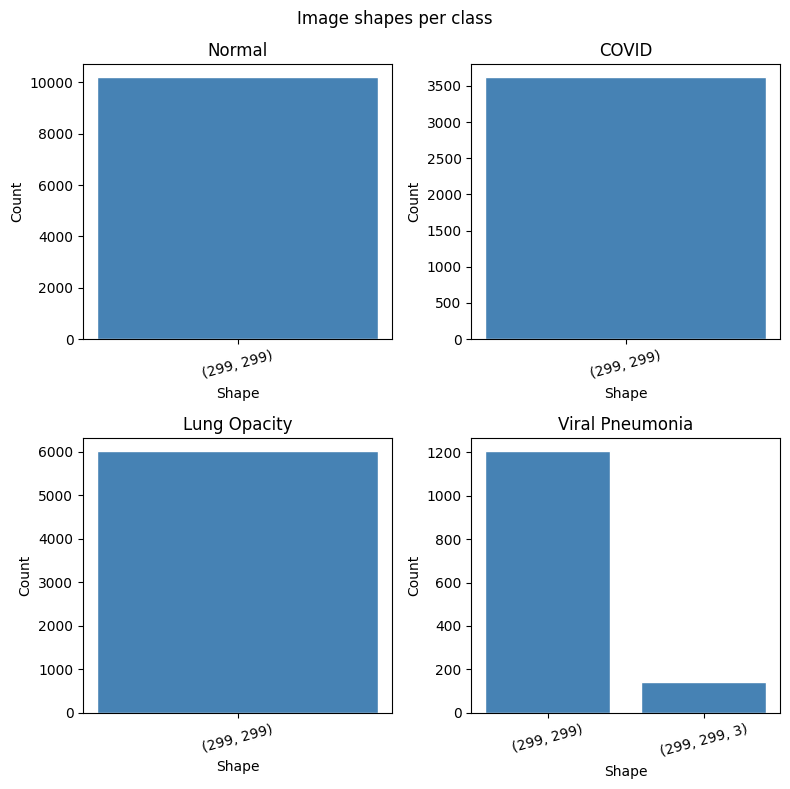

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, (class_name, path) in zip(axes.flatten(), paths.items()):
    shapes = check_shapes(class_name, "images")
    labels = [str(k) for k in shapes.keys()]
    counts = list(shapes.values())
    ax.bar(labels, counts, color='steelblue', edgecolor='white')
    ax.set_title(class_name)
    ax.set_xlabel('Shape')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Image shapes per class')
plt.tight_layout()
plt.show()

A few "viral pneumonia" samples are RGB images with 3 color channels. We need to convert them to Greyscale images so that our futur model always sees the same data type

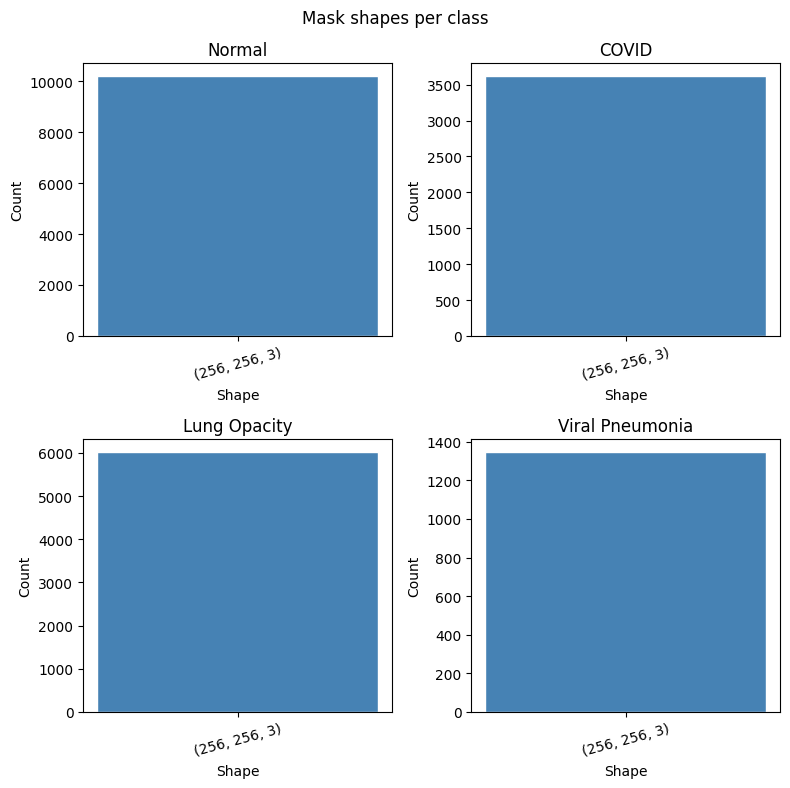

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, (class_name, path) in zip(axes.flatten(), paths.items()):
    shapes = check_shapes(class_name, "masks")
    labels = [str(k) for k in shapes.keys()]
    counts = list(shapes.values())
    ax.bar(labels, counts, color='steelblue', edgecolor='white')
    ax.set_title(class_name)
    ax.set_xlabel('Shape')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Mask shapes per class')
plt.tight_layout()
plt.show()

In [41]:
from PIL import Image

def preprocess_dataset():
    images = os.listdir(viral_pneumonia_path)
    for fname in images:
        img = plt.imread(os.path.join(viral_pneumonia_path, fname))
        if img.shape == (299, 299, 3):
            img_gray = img.mean(axis=2).astype(np.uint8)
            Image.fromarray(img_gray).save(os.path.join(viral_pneumonia_path, fname))

In [42]:
# paths variables
# 'Normal', 'COVID', 'Lung Opacity', 'Viral Pneumonia'

cls_name = "Normal"
path = paths[class_name]
images = os.listdir(path)
selected = images[np.random.randint(0, len(images))]
selected_path = os.path.join(path, selected)
print(plt.imread(selected_path))
print()
print((plt.imread(selected_path)*255).astype(np.uint8))

[[0.         0.         0.654902   ... 0.         0.         0.        ]
 [0.         0.         0.654902   ... 0.         0.         0.        ]
 [0.         0.         0.654902   ... 0.         0.         0.        ]
 ...
 [0.14509805 0.03921569 0.         ... 0.         0.03921569 0.14509805]
 [0.3019608  0.0627451  0.         ... 0.         0.0627451  0.3019608 ]
 [0.00784314 0.00784314 0.00392157 ... 0.00392157 0.00784314 0.00784314]]

[[  0   0 167 ...   0   0   0]
 [  0   0 167 ...   0   0   0]
 [  0   0 167 ...   0   0   0]
 ...
 [ 37  10   0 ...   0  10  37]
 [ 77  16   0 ...   0  16  77]
 [  2   2   1 ...   1   2   2]]


Images are normalized in range [0, 1]

Let's expand the pixel values to the range [0, 255]

# Outliers

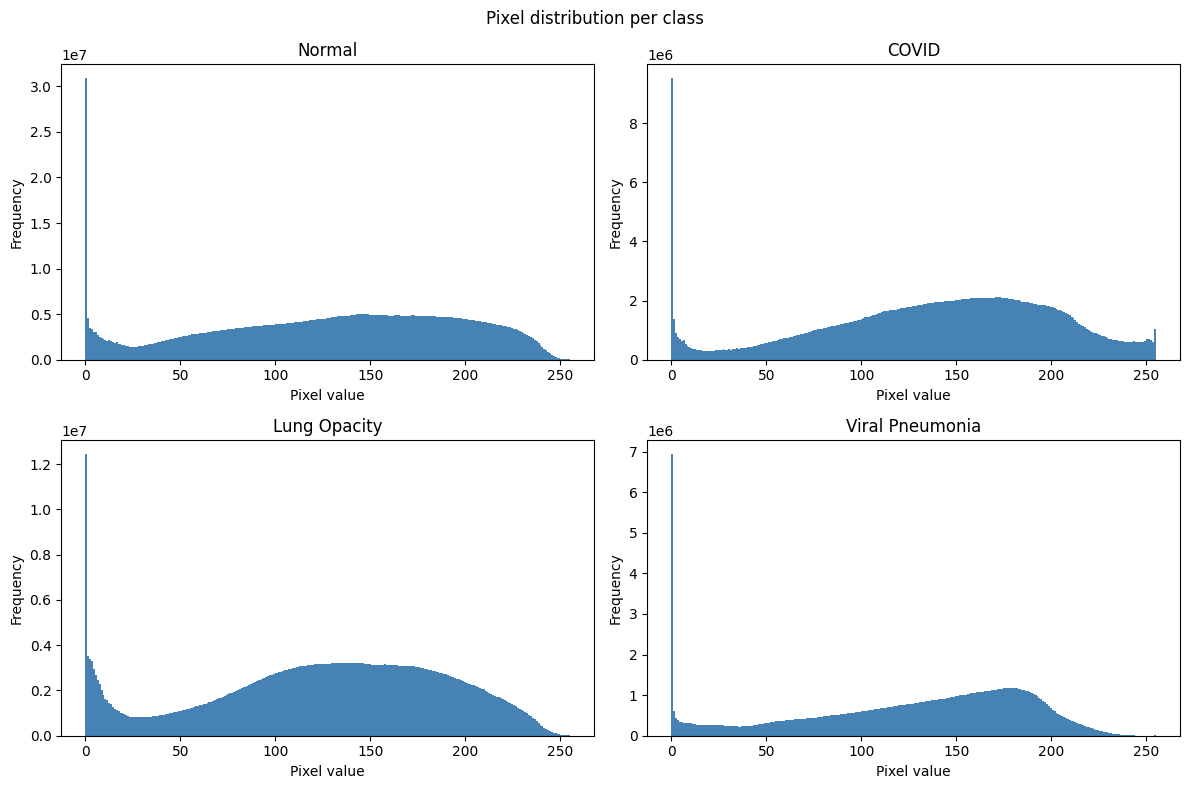

Normal: 0 outlier pixels (0.00%) | range: <-72.0 or >336.0
COVID: 0 outlier pixels (0.00%) | range: <-29.0 or >315.0
Lung Opacity: 0 outlier pixels (0.00%) | range: <-47.5 or >308.5
Viral Pneumonia: 0 outlier pixels (0.00%) | range: <-45.0 or >307.0


In [43]:
def analyze_pixels(class_name):
    path = paths[class_name]
    all_pixels = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        all_pixels.append(img.flatten())
    return np.concatenate(all_pixels)

pixel_data = {class_name: analyze_pixels(class_name) for class_name in paths}

# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_data.items()):
    ax.hist(pixels, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixel distribution per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_data.items():
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier pixels ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

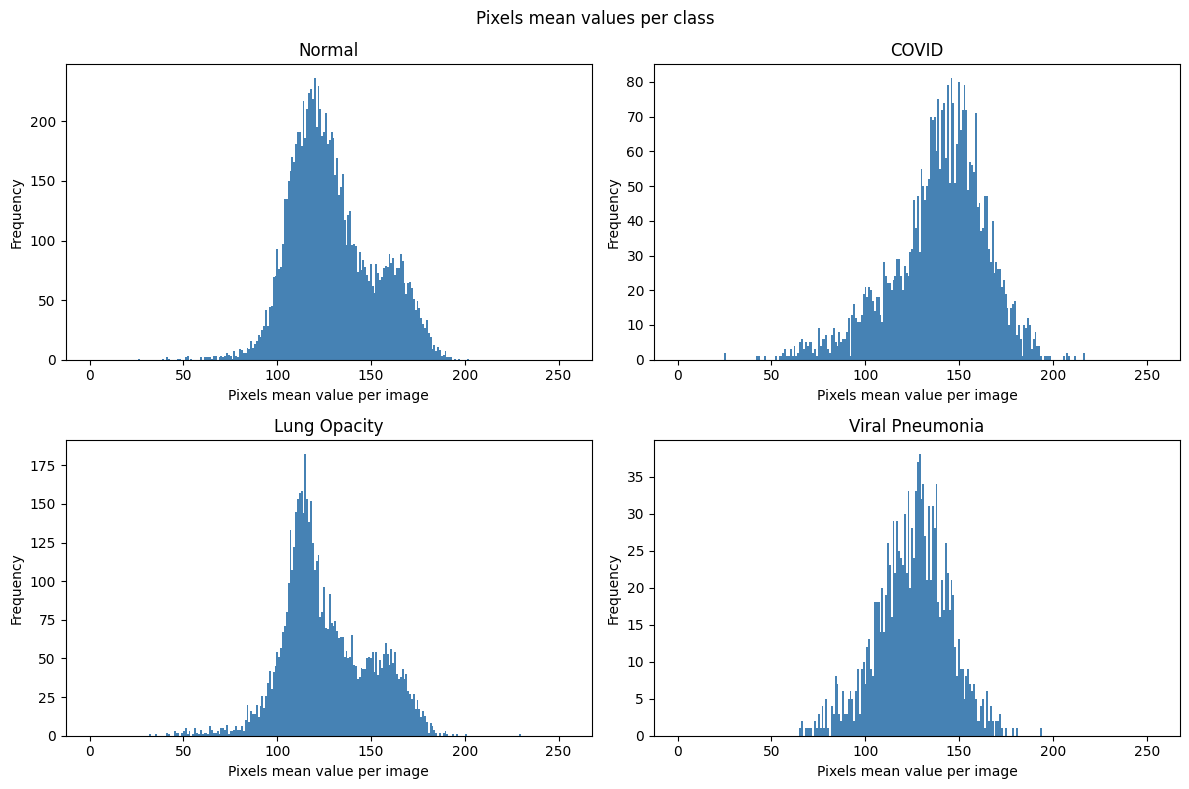

Normal: 0 outlier images (0.00%) | range: <-72.0 or >336.0
COVID: 0 outlier images (0.00%) | range: <-29.0 or >315.0
Lung Opacity: 0 outlier images (0.00%) | range: <-47.5 or >308.5
Viral Pneumonia: 0 outlier images (0.00%) | range: <-45.0 or >307.0


In [44]:
def analyze_pixels_means(class_name):
    path = paths[class_name]
    pixels_means = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        pixels_means.append(img.mean())
    return pixels_means

pixel_mean_data = {class_name: analyze_pixels_means(class_name) for class_name in paths}

# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_mean_data.items()):
    ax.hist(pixels, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixels mean value per image')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixels mean values per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_data.items():
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

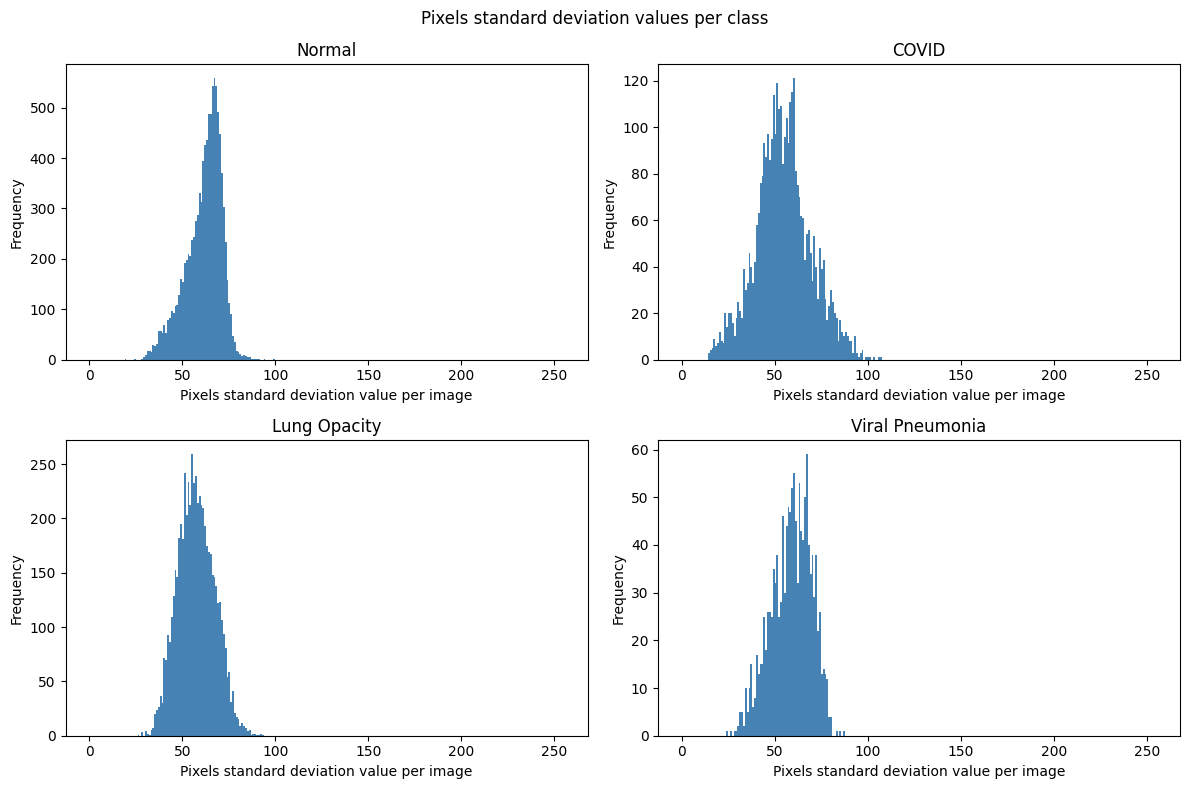

Normal: 0 outlier images (0.00%) | range: <-72.0 or >336.0
COVID: 0 outlier images (0.00%) | range: <-29.0 or >315.0
Lung Opacity: 0 outlier images (0.00%) | range: <-47.5 or >308.5
Viral Pneumonia: 0 outlier images (0.00%) | range: <-45.0 or >307.0


In [45]:
def analyze_pixels_std(class_name):
    path = paths[class_name]
    pixels_std = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        pixels_std.append(img.std())
    return pixels_std

pixel_std_data = {class_name: analyze_pixels_std(class_name) for class_name in paths}

# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_std_data.items()):
    ax.hist(pixels, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixels standard deviation value per image')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixels standard deviation values per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_data.items():
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

In [46]:
classes = ["COVID", "Lung Opacity", "Normal", "Viral Pneumonia"]
data = []
for class_name in classes:
    image_dir = paths[class_name]
    images = os.listdir(image_dir)

    for image_name in images:
        image_path = os.path.join(image_dir, image_name)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        min_pixel = np.min(image)
        max_pixel = np.max(image)
        mean_pixel = np.mean(image)
        std_pixel = np.std(image)
        height, width = image.shape
        
        # stockage
        data.append({
            "class": class_name,
            "image_name": image_name,
            "height": height,
            "width": width,
            "min_pixel": min_pixel,
            "max_pixel": max_pixel,
            "mean_pixel": mean_pixel,
            "std_pixel": std_pixel
        })

df_stats = pd.DataFrame(data)
df_stats.to_csv("../data/dataset_pixel_statistics.csv", index=False)

df_stats.head()


,class,image_name,height,width,min_pixel,max_pixel,mean_pixel,std_pixel
0,COVID,COVID-1.png,299,299,0,255,145.896847,51.816632
1,COVID,COVID-10.png,299,299,0,227,141.355466,40.623291
2,COVID,COVID-100.png,299,299,0,255,152.878570,73.778044
3,COVID,COVID-1000.png,299,299,0,252,162.771054,76.249129
4,COVID,COVID-1001.png,299,299,0,242,129.890784,66.179559


In [ ]:
df_stats = pd.read_csv("../data/dataset_pixel_statistics.csv")

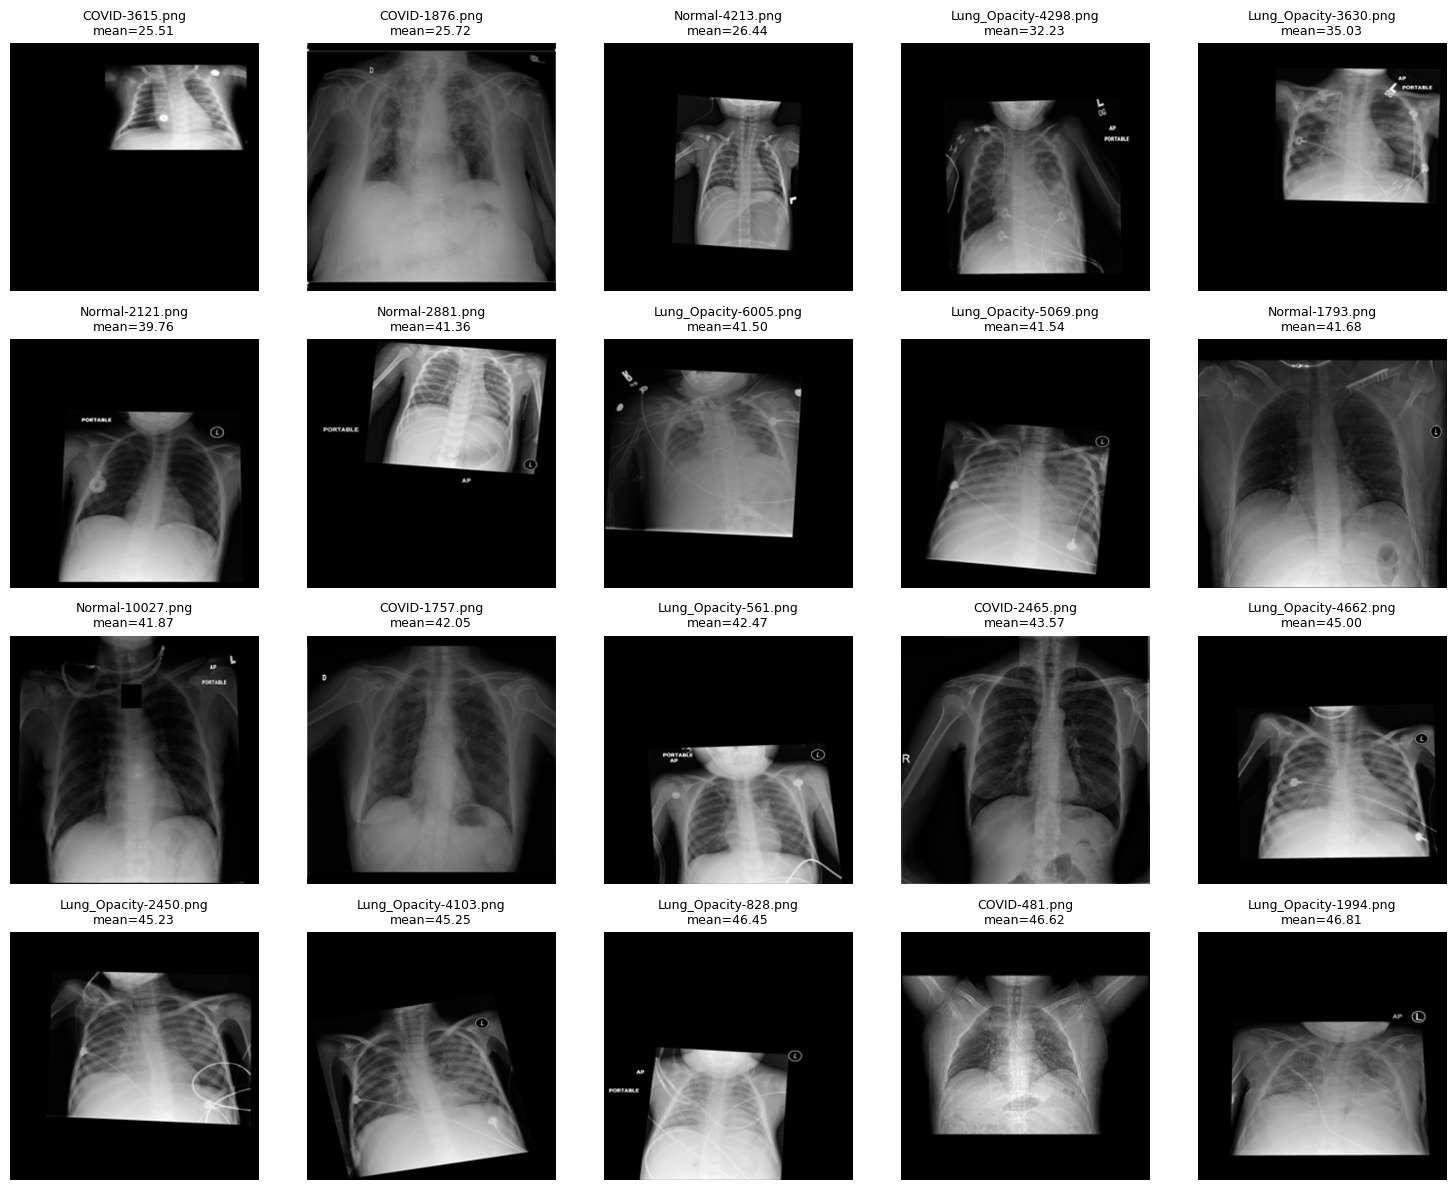

In [47]:
# 20 images avec les moyennes les plus faibles
lowest_mean_images = df_stats.nsmallest(20, "mean_pixel")
fig, axs = plt.subplots(4, 5, figsize=(15, 12))
for ax, (_, row) in zip(axs.flat, lowest_mean_images.iterrows()):
    image_path = os.path.join(paths[row["class"]], row["image_name"])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"{row['image_name']}\nmean={row['mean_pixel']:.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

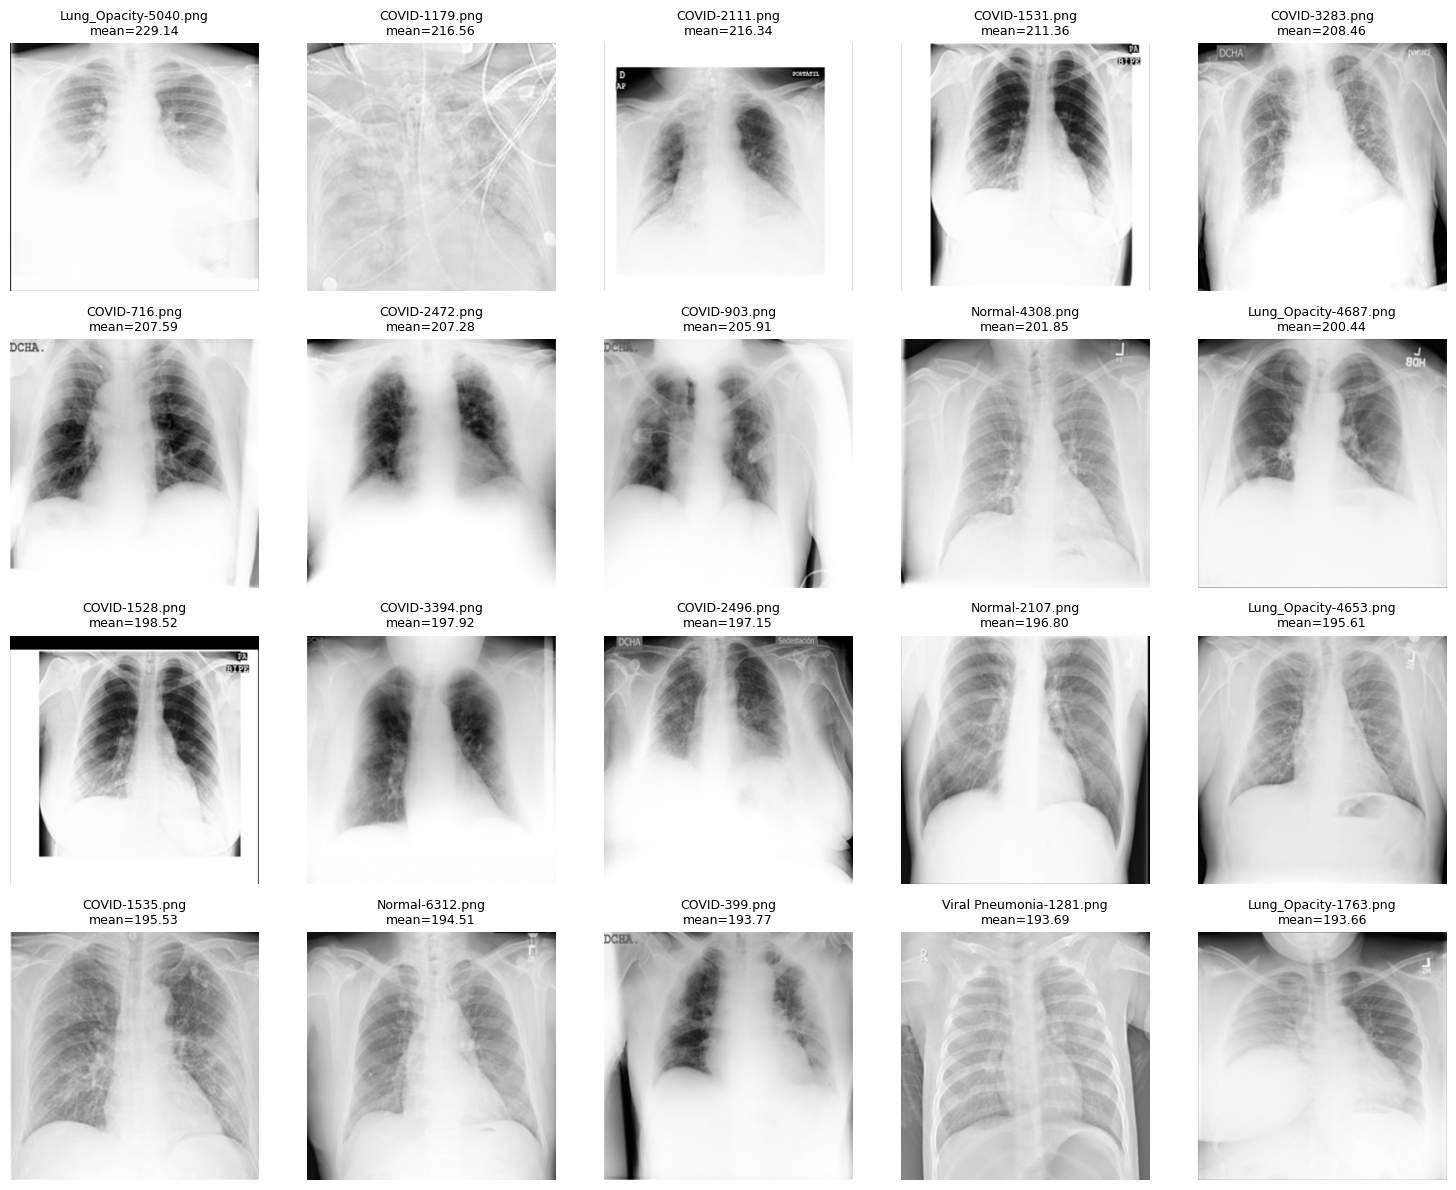

In [48]:
# 20 images avec les moyennes les plus fortes
highest_mean_images = df_stats.nlargest(20, "mean_pixel")
fig, axs = plt.subplots(4, 5, figsize=(15, 12))
for ax, (_, row) in zip(axs.flat, highest_mean_images.iterrows()):
    image_path = os.path.join(paths[row["class"]], row["image_name"])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"{row['image_name']}\nmean={row['mean_pixel']:.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

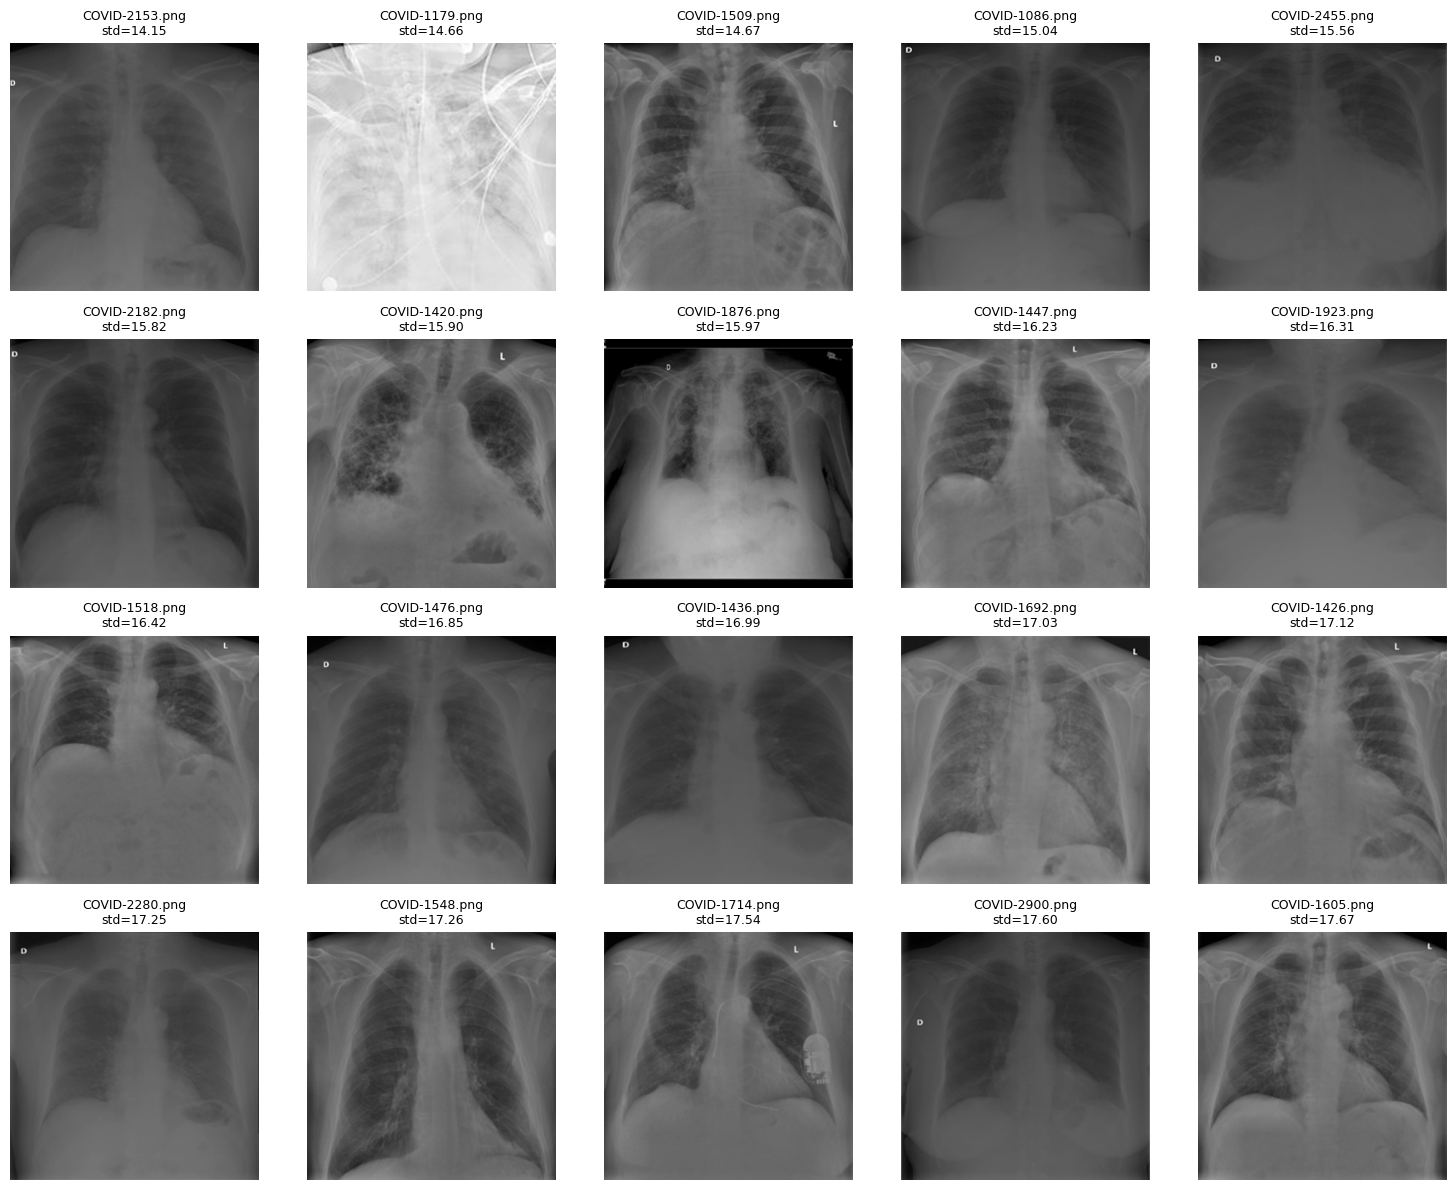

In [49]:
# 20 images avec les écart-types les plus faibles
lowest_std_images = df_stats.nsmallest(20, "std_pixel")
fig, axs = plt.subplots(4, 5, figsize=(15, 12))
for ax, (_, row) in zip(axs.flat, lowest_std_images.iterrows()):
    image_path = os.path.join(paths[row["class"]], row["image_name"])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"{row['image_name']}\nstd={row['std_pixel']:.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

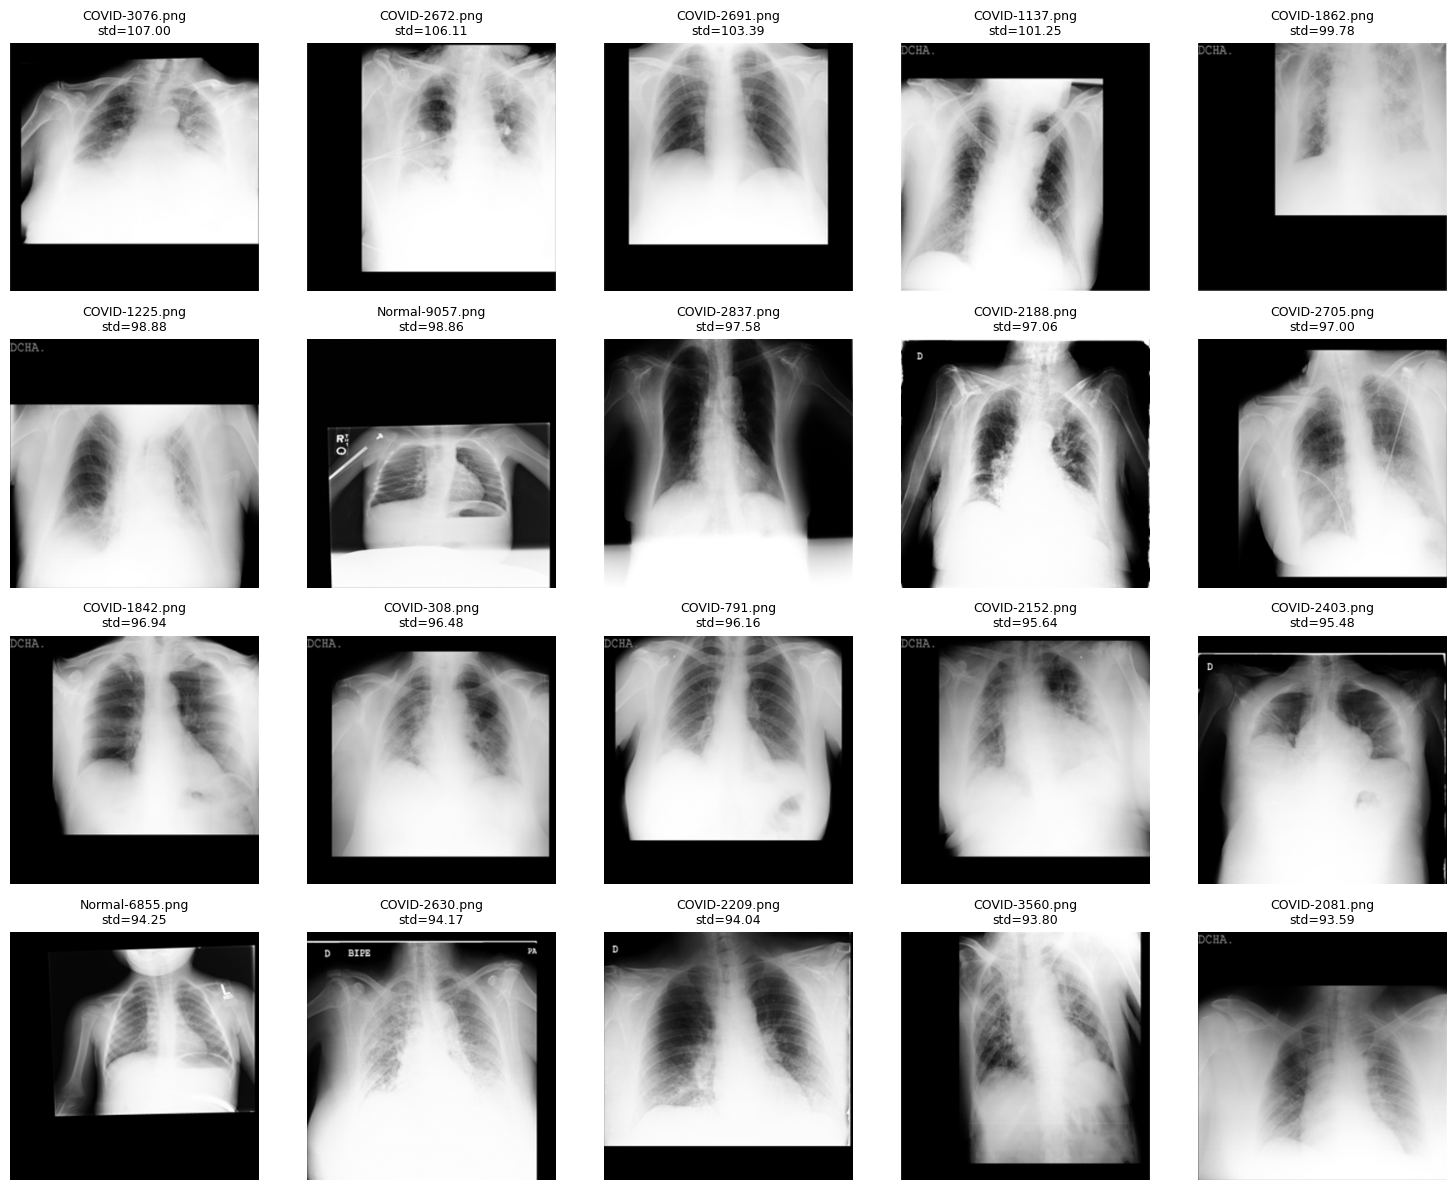

In [50]:
# 20 images avec les écart-types les plus forts
highest_std_images = df_stats.nlargest(20, "std_pixel")
fig, axs = plt.subplots(4, 5, figsize=(15, 12))
for ax, (_, row) in zip(axs.flat, highest_std_images.iterrows()):
    image_path = os.path.join(paths[row["class"]], row["image_name"])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"{row['image_name']}\nstd={row['std_pixel']:.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [62]:
def show_uniform_mean_images(df_stats, n_images=20):
    # bornes min/max
    min_mean = df_stats["mean_pixel"].min()
    max_mean = df_stats["mean_pixel"].max()
    # max_mean = 50
    # valeurs uniformément réparties
    target_means = np.linspace(min_mean, max_mean, n_images)
    selected_rows = []
    # trouver l'image la plus proche de chaque moyenne cible
    for target in target_means:
        idx = (df_stats["mean_pixel"] - target).abs().idxmin()
        selected_rows.append(df_stats.loc[idx])

    # affichage
    fig, axs = plt.subplots(4, 5, figsize=(15, 12))
    for ax, row in zip(axs.flat, selected_rows):
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(image, cmap="gray")
        ax.set_title(f"{row['image_name']}\nmean={row['mean_pixel']:.2f}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

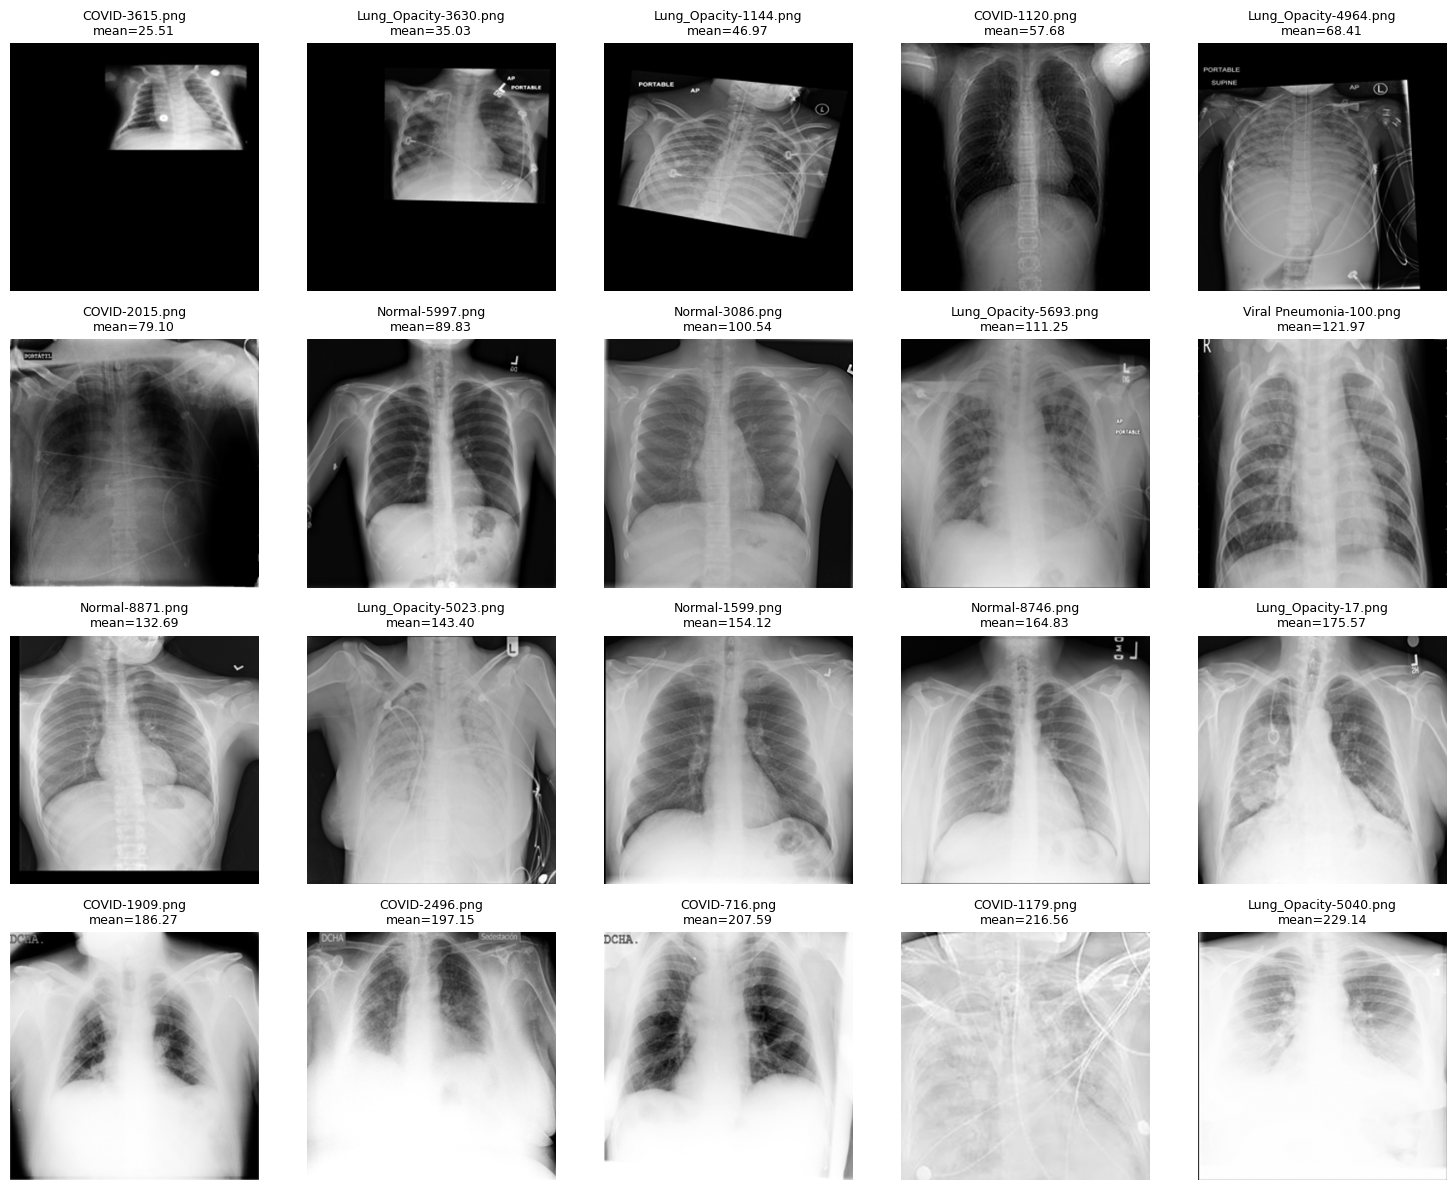

In [63]:
show_uniform_mean_images(df_stats)

In [64]:
def show_uniform_std_images(df_stats, n_images=20):
    # bornes min/max
    min_std = df_stats["std_pixel"].min()
    max_std = df_stats["std_pixel"].max()
    # max_std = 50
    # valeurs uniformément réparties
    target_std = np.linspace(min_std, max_std, n_images)
    selected_rows = []
    # trouver l'image la plus proche de chaque écart-type cible
    for target in target_std:
        idx = (df_stats["std_pixel"] - target).abs().idxmin()
        selected_rows.append(df_stats.loc[idx])

    # affichage
    fig, axs = plt.subplots(4, 5, figsize=(15, 12))
    for ax, row in zip(axs.flat, selected_rows):
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(image, cmap="gray")
        ax.set_title(f"{row['image_name']}\nstd={row['std_pixel']:.2f}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

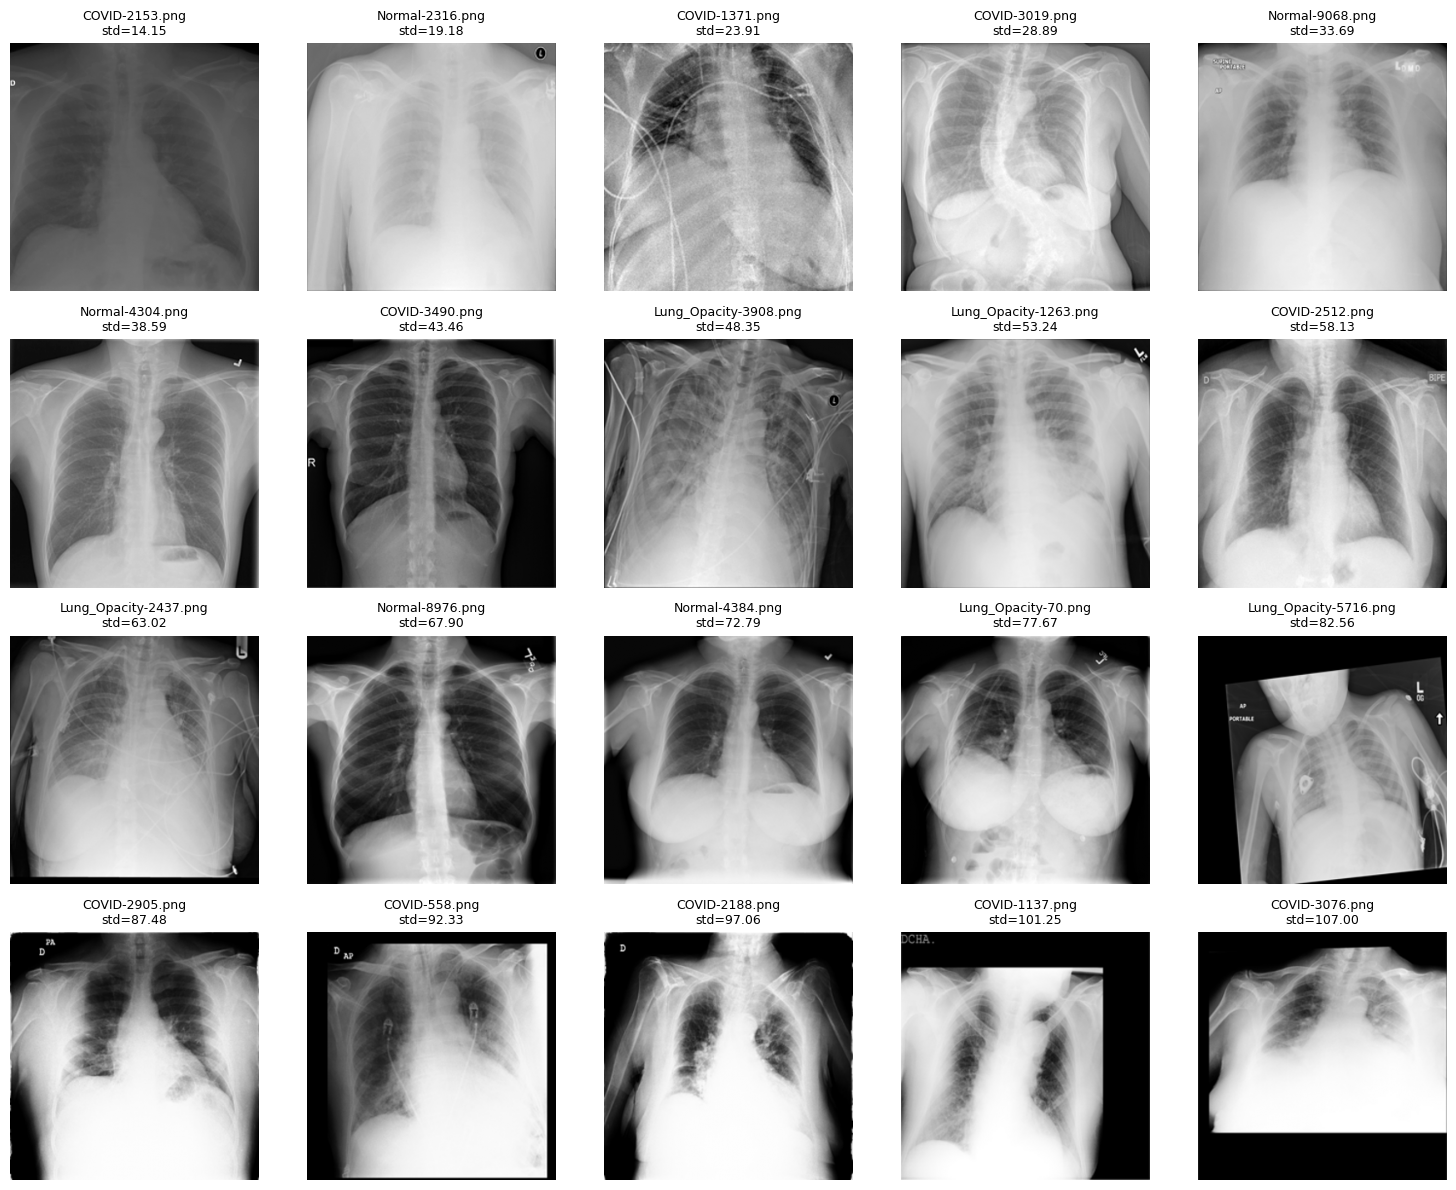

In [65]:
show_uniform_std_images(df_stats)